# Epoch amplitude vs 0: mass-univariate permutation analysis

这个 notebook 检验 CPP 通道平均后的 epoch amplitude 在整个时间序列上是否显著偏离 0。
统计方法是逐时间点的 one-sample mass-univariate permutation t-test，并使用 permutation-based 多重比较校正。

In [13]:
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import logging
from scipy.stats import sem
from mne.stats import permutation_t_test


In [14]:
# == Configuration ==
# === Logging format: timestamp - level - message ===
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURRENT_DIR = Path.cwd()
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess'

# === Subject lists ===
SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120,
    #1124, 1126, 1131, 1132, 1135, 1136,
    #1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    #1182, 1215, 1216, 1219, 1223, 1227, 1233,
    #1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    #1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
]]

# === ERP parameters ===
ERP_TMIN, ERP_TMAX = -0.5, 2.0
BASELINE_TMIN, BASELINE_TMAX = -0.25, 0.0
CPP_CHANNELS = ['POz', 'CPz', 'CP2', 'CP1', 'P3', 'Pz', 'P2', 'PO3', 'PO4']

# === Permutation parameters ===
ALPHA = 0.05
N_PERMUTATIONS = 5000
RANDOM_STATE = 42


In [15]:
SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120, 
    1124, 1126, 1131, 1132, 1135, 1136,
    1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    1182, 1215, 1216, 1219, 1223, 1227, 1233,
    1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
    ]]
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess' 
PATH_PREPROCESS_DATA_BIDS = Path('/Users/hyijie/Desktop/CPP_local_own/3_Data/preprocessData/CPP_low-level-2_Kosciessa_et_al_2021')
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))

beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

cpp_timecourses = []
trial_counts = []
included_subjects = []
times = None

for sub_id in SUBJECT_IDS:
    if sub_id not in beh_by_sub or sub_id not in eeg_by_sub:
        logger.warning(f'{sub_id}: missing EEG or behavior file, skipping')
        continue

    path_eeg = eeg_by_sub[sub_id]
    path_behavior = beh_by_sub[sub_id]
    logger.info(f'Processing subject: {sub_id}')

    data_behavior = pd.read_csv(path_behavior)
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f'{sub_id}: rt column missing in behavior, skipping')
        continue

    raw = mne.io.read_raw_brainvision(path_eeg, preload=True, verbose='ERROR')
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    raw.set_channel_types({
        'VEOG': 'eog',
        'HEOGL': 'eog',
        'HEOGR': 'eog',
        'ECG': 'ecg',
    })
    raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')

    stim_event_id = {'Stimulus/S  8': 8}
    stim_value = 8
    stim_events = events[events[:, 2] == stim_value]

    assert len(stim_events) == len(data_behavior), f'{sub_id}: events and data_behavior have different lengths'

    epochs_full = mne.Epochs(
        raw,
        events=stim_events,
        event_id=stim_event_id,
        tmin=ERP_TMIN,
        tmax=ERP_TMAX,
        baseline=(BASELINE_TMIN, BASELINE_TMAX),
        reject={'eeg': 200e-5},
        metadata=data_behavior,
        preload=True,
        event_repeated='drop',
        verbose='ERROR',
    )

    available_cpp_channels = [ch for ch in CPP_CHANNELS if ch in epochs_full.ch_names]
    if len(available_cpp_channels) == 0:
        logger.warning(f'{sub_id}: no CPP channels available, skipping')
        continue

    evoked = epochs_full.average()
    if times is None:
        times = evoked.times.copy()

    cpp_timecourse = evoked.copy().pick(available_cpp_channels).data.mean(axis=0)
    cpp_timecourses.append(cpp_timecourse)
    trial_counts.append(len(epochs_full))
    included_subjects.append(sub_id)

cpp_timecourses = np.stack(cpp_timecourses, axis=0)

print(f'Included subjects: {len(included_subjects)}')
print(included_subjects)
print(f'CPP timecourse array shape: {cpp_timecourses.shape}')
print(f'Clean epoch counts per subject: {trial_counts}')


2026-06-13 13:31:31,433 - INFO - Processing subject: sub-1117
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_47484/412078260.py:47: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')
2026-06-13 13:31:32,596 - INFO - Processing subject: sub-1118
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_47484/412078260.py:47: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_cas

Included subjects: 41
['sub-1117', 'sub-1118', 'sub-1120', 'sub-1124', 'sub-1126', 'sub-1131', 'sub-1132', 'sub-1135', 'sub-1136', 'sub-1151', 'sub-1160', 'sub-1164', 'sub-1167', 'sub-1169', 'sub-1172', 'sub-1173', 'sub-1178', 'sub-1182', 'sub-1215', 'sub-1216', 'sub-1219', 'sub-1223', 'sub-1227', 'sub-1233', 'sub-1234', 'sub-1237', 'sub-1240', 'sub-1243', 'sub-1245', 'sub-1247', 'sub-1250', 'sub-1239', 'sub-1252', 'sub-1257', 'sub-1261', 'sub-1265', 'sub-1266', 'sub-1268', 'sub-1270', 'sub-1276', 'sub-1281']
CPP timecourse array shape: (41, 641)
Clean epoch counts per subject: [256, 256, 256, 256, 256, 256, 207, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256]


/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_47484/412078260.py:47: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')


In [16]:
T_obs, p_values, H0 = permutation_t_test(
    cpp_timecourses,
    n_permutations=N_PERMUTATIONS,
    tail=0,
    seed=RANDOM_STATE,
    verbose=False,
)

significant_mask = p_values < ALPHA
significant_segments = []
significant_idx = np.where(significant_mask)[0]

if len(significant_idx) > 0:
    start_idx = significant_idx[0]
    end_idx = significant_idx[0]

    for idx in significant_idx[1:]:
        if idx == end_idx + 1:
            end_idx = idx
        else:
            significant_segments.append({
                't_start': float(times[start_idx]),
                't_end': float(times[end_idx]),
                'duration_ms': float((times[end_idx] - times[start_idx]) * 1000),
                'n_timepoints': int(end_idx - start_idx + 1),
                'min_p_value': float(p_values[start_idx:end_idx + 1].min()),
            })
            start_idx = idx
            end_idx = idx

    significant_segments.append({
        't_start': float(times[start_idx]),
        't_end': float(times[end_idx]),
        'duration_ms': float((times[end_idx] - times[start_idx]) * 1000),
        'n_timepoints': int(end_idx - start_idx + 1),
        'min_p_value': float(p_values[start_idx:end_idx + 1].min()),
    })

if len(significant_segments) == 0:
    print('No significant timepoints: CPP amplitude is not significantly different from 0 after permutation-based multiple-comparison correction.')
else:
    display(pd.DataFrame(significant_segments))


,t_start,t_end,duration_ms,n_timepoints,min_p_value
0,-0.500000,-0.218750,281.25000,73,0.0004
1,-0.019531,0.109375,128.90625,34,0.0002
2,0.136719,0.144531,7.81250,3,0.0206
3,0.234375,0.917969,683.59375,176,0.0002
4,0.941406,0.945312,3.90625,2,0.0238
5,0.972656,0.980469,7.81250,3,0.0144
6,1.011719,1.011719,0.00000,1,0.0454
7,1.207031,1.214844,7.81250,3,0.0102
8,1.238281,1.250000,11.71875,4,0.0038
9,1.269531,1.285156,15.62500,5,0.0054


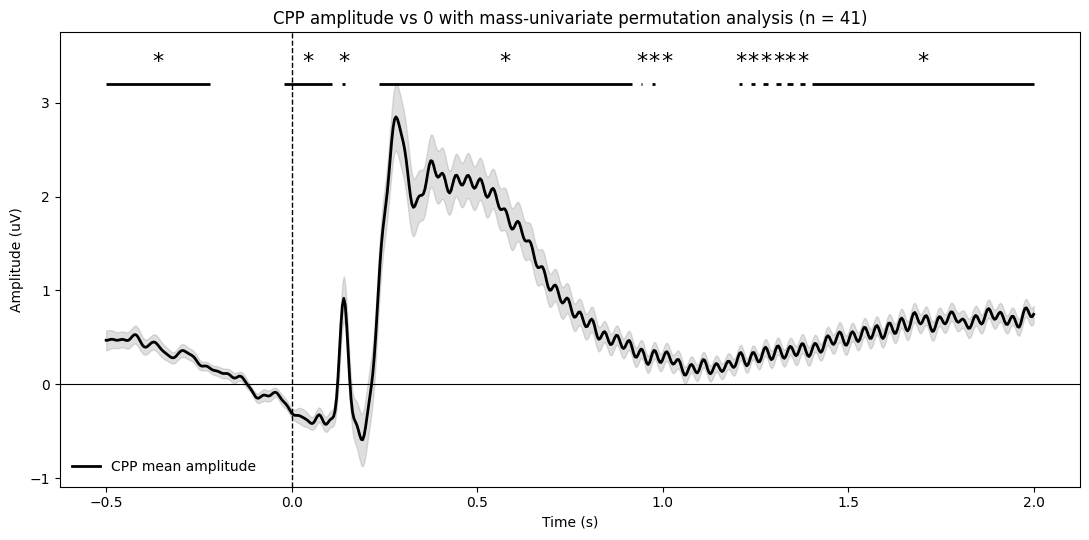

In [17]:
mean_uv = cpp_timecourses.mean(axis=0) * 1e6
sem_uv = sem(cpp_timecourses, axis=0) * 1e6

plt.figure(figsize=(11, 5.5))
plt.plot(times, mean_uv, color='black', linewidth=2, label='CPP mean amplitude')
plt.fill_between(times, mean_uv - sem_uv, mean_uv + sem_uv, color='gray', alpha=0.25)

line_y = mean_uv.max() + 0.35
star_y = mean_uv.max() + 0.48

for segment in significant_segments:
    plt.hlines(line_y, segment['t_start'], segment['t_end'], color='black', linewidth=2)
    plt.text(
        (segment['t_start'] + segment['t_end']) / 2,
        star_y,
        '*',
        ha='center',
        va='bottom',
        fontsize=16,
        color='black',
    )

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(mean_uv.min() - 0.5, mean_uv.max() + 0.9)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.title(f'CPP amplitude vs 0 with mass-univariate permutation analysis (n = {len(included_subjects)})')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


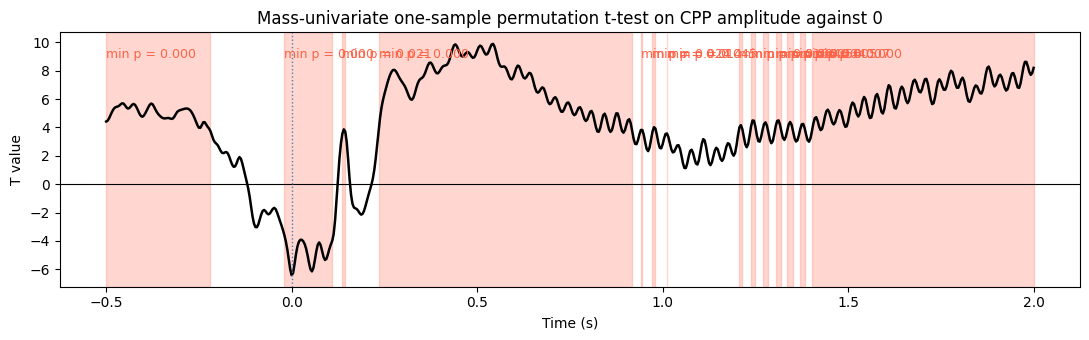

In [18]:
plt.figure(figsize=(11, 3.5))
plt.plot(times, T_obs, color='black', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8)

for segment in significant_segments:
    plt.axvspan(segment['t_start'], segment['t_end'], color='tomato', alpha=0.25)
    plt.text(segment['t_start'], T_obs.max() * 0.9, f"min p = {segment['min_p_value']:.3f}", color='tomato', fontsize=9)

plt.axvline(0, color='steelblue', linestyle=':', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('T value')
plt.title('Mass-univariate one-sample permutation t-test on CPP amplitude against 0')
plt.tight_layout()
plt.show()
